In [ ]:
import torch
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU name: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import shutil

# Copy label_map.json from Drive to dataset folder
shutil.copy(
    '/content/drive/MyDrive/label_map.json',
    '/content/dataset/label_map.json'
)

# Now read and check it
import json
with open('/content/dataset/label_map.json', 'r') as f:
    label_map = json.load(f)

print(label_map)

In [ ]:
import os

# This lists everything in your Google Drive root
for item in os.listdir('/content/drive/MyDrive'):
    print(item)


Classroom
Bank shr (1).pdf
Bank shr.pdf
IMG-20251015-WA0000.jpg
some more like the second photo.gdoc
Tutorial_problems_Multivariable.gdoc
Python_Cheatsheet_2025.ipynb
FCsubmission
Tutorial_1.pdf
Tutorial_1.gdoc
FINAL_ROBOTICS_SUBMISSION.zip
Lec 6 & 7 merged.gdoc
auto cad training.dwg
Electronic Devices Chapter-1.gdoc
cpicimsportal.pdf
ec25bt021_Photo.jpeg
ec25bt021_Manifesto (1).pdf
ec25bt021_Manifesto.pdf
ec25bt021_Declaration.pdf
EuroSAT_Dataset.zip
Colab Notebooks
best_rgb_model.pth
best_efficientnet_rgb.pth
rgb_predictions.csv
gradcam_results.png
gradcam_results_v2.png
gradcam_results_v3.png
lime_results.png
best_efficientnet_ms.pth
ms_predictions.csv
confusion_matrix_ms.png
Shreya Aadhar.pdf
Aadhaar_260612_005315.jpg
IL0900599481000_260612_010401.pdf
iitbastronomy
20260614_225531.jpg
20260614_225609.jpg
Assignment1
Screenshot 2026-06-15 005703.pdf
label_map.json


In [ ]:
import zipfile
import os

print("Starting unzip... this will take 1-2 minutes")

with zipfile.ZipFile('/content/drive/MyDrive/EuroSAT_Dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Done!")
print("Contents:", os.listdir('/content/dataset'))

Starting unzip... this will take 1-2 minutes
Done!
Contents: ['train.csv', 'EuroSAT', 'validation.csv', 'EuroSATallBands_test_flat', 'EuroSATallBands', 'label_map.json', 'EuroSAT_test_flat']


In [ ]:
import os

# ============================================
# RGB DATASET
# ============================================
print("=" * 50)
print("RGB DATASET (EuroSAT)")
print("=" * 50)

print("\n--- Train ---")
for cls in sorted(os.listdir('/content/dataset/EuroSAT/train')):
    count = len(os.listdir(f'/content/dataset/EuroSAT/train/{cls}'))
    print(f"  {cls}: {count} images")

print("\n--- Validation ---")
for cls in sorted(os.listdir('/content/dataset/EuroSAT/val')):
    count = len(os.listdir(f'/content/dataset/EuroSAT/val/{cls}'))
    print(f"  {cls}: {count} images")

print("\n--- Test (flat, unlabeled) ---")
test_rgb = os.listdir('/content/dataset/EuroSAT_test_flat')
print(f"  Total test images: {len(test_rgb)}")
print(f"  Sample filenames: {test_rgb[:3]}")

# ============================================
# MULTISPECTRAL DATASET
# ============================================
print("\n" + "=" * 50)
print("MULTISPECTRAL DATASET (EuroSATallBands)")
print("=" * 50)

print("\n--- Train ---")
for cls in sorted(os.listdir('/content/dataset/EuroSATallBands/train')):
    count = len(os.listdir(f'/content/dataset/EuroSATallBands/train/{cls}'))
    print(f"  {cls}: {count} images")

print("\n--- Validation ---")
for cls in sorted(os.listdir('/content/dataset/EuroSATallBands/val')):
    count = len(os.listdir(f'/content/dataset/EuroSATallBands/val/{cls}'))
    print(f"  {cls}: {count} images")

print("\n--- Test (flat, unlabeled) ---")
test_ms = os.listdir('/content/dataset/EuroSATallBands_test_flat')
print(f"  Total test images: {len(test_ms)}")
print(f"  Sample filenames: {test_ms[:3]}")

# ============================================
# CSV FILES
# ============================================
print("\n" + "=" * 50)
print("CSV FILES")
print("=" * 50)

import pandas as pd
train_csv = pd.read_csv('/content/dataset/train.csv')
val_csv = pd.read_csv('/content/dataset/validation.csv')

print("\n--- train.csv ---")
print(f"  Shape: {train_csv.shape}")
print(f"  Columns: {list(train_csv.columns)}")
print(train_csv.head(3))

print("\n--- validation.csv ---")
print(f"  Shape: {val_csv.shape}")
print(f"  Columns: {list(val_csv.columns)}")
print(val_csv.head(3))

RGB DATASET (EuroSAT)

--- Train ---
  AnnualCrop: 2100 images
  Forest: 2100 images
  HerbaceousVegetation: 2100 images
  Highway: 1750 images
  Industrial: 1750 images
  Pasture: 1400 images
  PermanentCrop: 1750 images
  Residential: 2100 images
  River: 1750 images
  SeaLake: 2100 images

--- Validation ---
  AnnualCrop: 450 images
  Forest: 450 images
  HerbaceousVegetation: 450 images
  Highway: 375 images
  Industrial: 375 images
  Pasture: 300 images
  PermanentCrop: 375 images
  Residential: 450 images
  River: 375 images
  SeaLake: 450 images

--- Test (flat, unlabeled) ---
  Total test images: 4050
  Sample filenames: ['test_185.jpg', 'test_1600.jpg', 'test_926.jpg']

MULTISPECTRAL DATASET (EuroSATallBands)

--- Train ---
  AnnualCrop: 2100 images
  Forest: 2100 images
  HerbaceousVegetation: 2100 images
  Highway: 1750 images
  Industrial: 1750 images
  Pasture: 1400 images
  PermanentCrop: 1750 images
  Residential: 2100 images
  River: 1750 images
  SeaLake: 2100 images



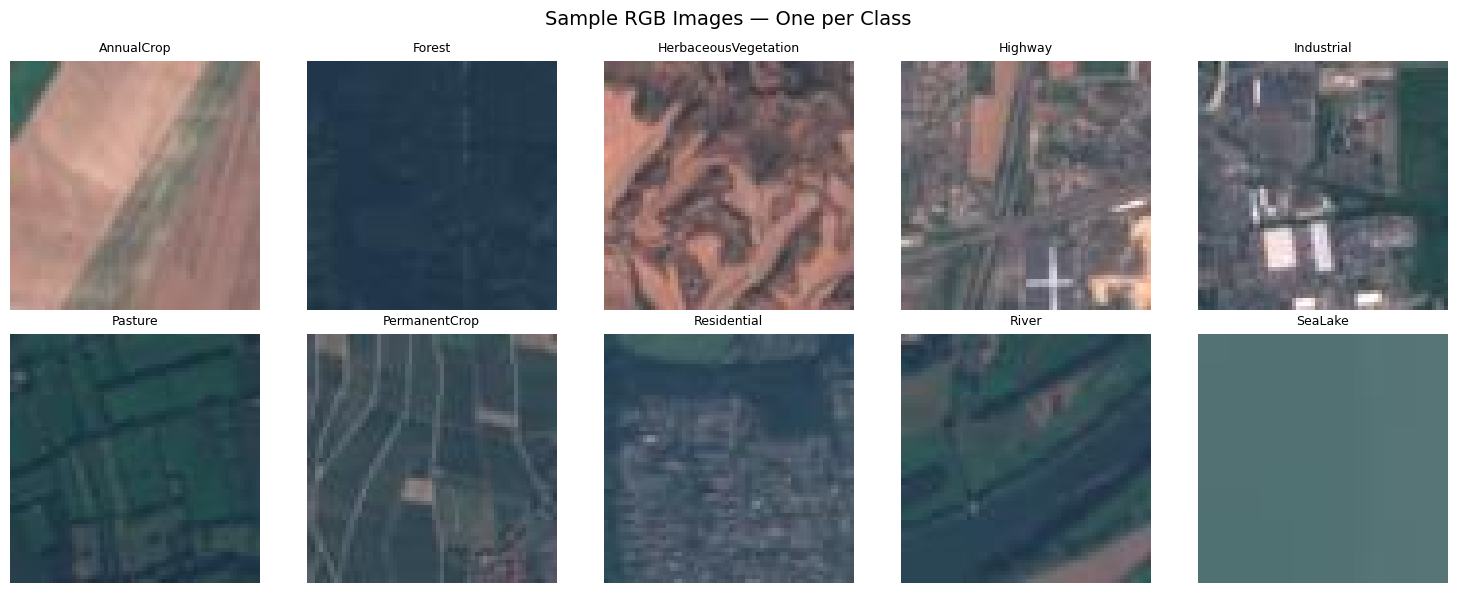

Image size: (64, 64)
Image mode: RGB


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# All 10 classes
classes = sorted(os.listdir('/content/dataset/EuroSAT/train'))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample RGB Images — One per Class', fontsize=14)

for idx, cls in enumerate(classes):
    # Grab the first image from each class
    folder = f'/content/dataset/EuroSAT/train/{cls}'
    img_name = os.listdir(folder)[0]
    img = Image.open(f'{folder}/{img_name}')

    row, col = idx // 5, idx % 5
    axes[row, col].imshow(img)
    axes[row, col].set_title(cls, fontsize=9)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Also print image size
print(f"Image size: {img.size}")
print(f"Image mode: {img.mode}")

In [ ]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

# ============================================
# Step 1 — Define transforms (image preprocessing)
# ============================================

# Training transforms — includes augmentation to make model stronger
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),         # keep at 64x64 (already this size)
    transforms.RandomHorizontalFlip(),   # randomly flip image left-right
    transforms.RandomVerticalFlip(),     # randomly flip image up-down
    transforms.RandomRotation(15),       # randomly rotate up to 15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # slight color changes
    transforms.ToTensor(),               # convert image to numbers (0-1 range)
    transforms.Normalize(               # normalize using ImageNet stats
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation transforms — NO augmentation, just clean processing
val_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================================
# Step 2 — Load datasets
# ============================================
train_dataset = datasets.ImageFolder(
    root='/content/dataset/EuroSAT/train',
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root='/content/dataset/EuroSAT/val',
    transform=val_transforms
)

# ============================================
# Step 3 — Create DataLoaders
# ============================================
train_loader = DataLoader(
    train_dataset,
    batch_size=32,    # process 32 images at a time
    shuffle=True,     # mix up the order every epoch
    num_workers=2     # use 2 CPU threads to load data
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,    # no need to shuffle validation
    num_workers=2
)

# ============================================
# Step 4 — Verify everything
# ============================================
print("Classes:", train_dataset.classes)
print("Class to index:", train_dataset.class_to_idx)
print(f"\nTraining images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"\nTraining batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

# Check one batch shape
images, labels = next(iter(train_loader))
print(f"\nOne batch — images shape: {images.shape}")
print(f"One batch — labels shape: {labels.shape}")

Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Class to index: {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}

Training images: 18900
Validation images: 4050

Training batches: 591
Validation batches: 127

One batch — images shape: torch.Size([32, 3, 64, 64])
One batch — labels shape: torch.Size([32])


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# Load pretrained ResNet18
model = models.resnet18(weights='IMAGENET1K_V1')

# Modify the final layer for 10 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

# Move model to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Verify
print("Device:", device)
print("Model's final layer:", model.fc)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]


Device: cuda
Model's final layer: Linear(in_features=512, out_features=10, bias=True)

Total parameters: 11,181,642
Trainable parameters: 11,181,642


In [ ]:
import torch.optim as optim

# ============================================
# Loss function and optimizer
# ============================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# ============================================
# Training loop
# ============================================
num_epochs = 10
best_val_acc = 0.0

for epoch in range(num_epochs):
    # --- Training phase ---
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Track accuracy
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    # --- Validation phase ---
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    # Calculate accuracies
    train_acc = 100. * train_correct / train_total
    val_acc = 100. * val_correct / val_total

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_rgb_model.pth')
        print(f"Epoch {epoch+1}/{num_epochs} → Train Loss: {train_loss/len(train_loader):.3f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% ⭐ BEST")
    else:
        print(f"Epoch {epoch+1}/{num_epochs} → Train Loss: {train_loss/len(train_loader):.3f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    scheduler.step()

print(f"\nTraining complete! Best validation accuracy: {best_val_acc:.2f}%")

Epoch 1/10 → Train Loss: 0.698 | Train Acc: 77.30% | Val Acc: 84.15% ⭐ BEST
Epoch 2/10 → Train Loss: 0.459 | Train Acc: 84.97% | Val Acc: 90.94% ⭐ BEST
Epoch 3/10 → Train Loss: 0.381 | Train Acc: 87.57% | Val Acc: 91.33% ⭐ BEST
Epoch 4/10 → Train Loss: 0.338 | Train Acc: 88.53% | Val Acc: 90.54%
Epoch 5/10 → Train Loss: 0.321 | Train Acc: 89.26% | Val Acc: 89.80%
Epoch 6/10 → Train Loss: 0.203 | Train Acc: 93.03% | Val Acc: 95.85% ⭐ BEST
Epoch 7/10 → Train Loss: 0.162 | Train Acc: 94.41% | Val Acc: 95.58%
Epoch 8/10 → Train Loss: 0.148 | Train Acc: 95.01% | Val Acc: 95.88% ⭐ BEST
Epoch 9/10 → Train Loss: 0.136 | Train Acc: 95.21% | Val Acc: 96.05% ⭐ BEST
Epoch 10/10 → Train Loss: 0.131 | Train Acc: 95.49% | Val Acc: 95.95%

Training complete! Best validation accuracy: 96.05%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader

# ============================================
# Data Pipeline
# ============================================
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root='/content/dataset/EuroSAT/train', transform=train_transforms)
val_dataset = datasets.ImageFolder(root='/content/dataset/EuroSAT/val', transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print("✅ Data loaded!")
print(f"Train: {len(train_dataset)} images | Val: {len(val_dataset)} images")

# ============================================
# Model
# ============================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.resnet18(weights='IMAGENET1K_V1')
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)
model = model.to(device)

print(f"✅ Model ready on {device}")

# ============================================
# Training Setup
# ============================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# ============================================
# Training Loop
# ============================================
num_epochs = 10
best_val_acc = 0.0

print("\n🚀 Starting training...\n")

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    train_acc = 100. * train_correct / train_total
    val_acc = 100. * val_correct / val_total

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/content/drive/MyDrive/best_rgb_model.pth')
        print(f"Epoch {epoch+1}/{num_epochs} → Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% ⭐ BEST SAVED")
    else:
        print(f"Epoch {epoch+1}/{num_epochs} → Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    scheduler.step()

print(f"\n✅ Training complete! Best Val Accuracy: {best_val_acc:.2f}%")

✅ Data loaded!
Train: 18900 images | Val: 4050 images
✅ Model ready on cuda

🚀 Starting training...

Epoch 1/10 → Train Acc: 78.31% | Val Acc: 88.15% ⭐ BEST SAVED
Epoch 2/10 → Train Acc: 85.26% | Val Acc: 79.19%
Epoch 3/10 → Train Acc: 87.11% | Val Acc: 88.54% ⭐ BEST SAVED
Epoch 4/10 → Train Acc: 88.79% | Val Acc: 86.86%
Epoch 5/10 → Train Acc: 88.97% | Val Acc: 93.23% ⭐ BEST SAVED
Epoch 6/10 → Train Acc: 93.74% | Val Acc: 95.36% ⭐ BEST SAVED
Epoch 7/10 → Train Acc: 94.85% | Val Acc: 95.95% ⭐ BEST SAVED
Epoch 8/10 → Train Acc: 94.95% | Val Acc: 95.51%
Epoch 9/10 → Train Acc: 95.24% | Val Acc: 96.17% ⭐ BEST SAVED
Epoch 10/10 → Train Acc: 95.69% | Val Acc: 95.93%

✅ Training complete! Best Val Accuracy: 96.17%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader

# ============================================
# Data Pipeline
# ============================================
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root='/content/dataset/EuroSAT/train', transform=train_transforms)
val_dataset = datasets.ImageFolder(root='/content/dataset/EuroSAT/val', transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print("✅ Data loaded!")

# ============================================
# EfficientNet-B0 Model
# ============================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load pretrained EfficientNet-B0
model = models.efficientnet_b0(weights='IMAGENET1K_V1')

# Replace final layer with 10 classes
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 10)

model = model.to(device)

print(f"✅ EfficientNet-B0 ready on {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# ============================================
# Training Setup
# ============================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

# ============================================
# Training Loop
# ============================================
num_epochs = 15
best_val_acc = 0.0

print("\n🚀 Starting EfficientNet training...\n")

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    # Validation phase
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    train_acc = 100. * train_correct / train_total
    val_acc = 100. * val_correct / val_total

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/content/drive/MyDrive/best_efficientnet_rgb.pth')
        print(f"Epoch {epoch+1}/{num_epochs} → Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% ⭐ BEST SAVED")
    else:
        print(f"Epoch {epoch+1}/{num_epochs} → Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    scheduler.step()

print(f"\n✅ Training complete! Best Val Accuracy: {best_val_acc:.2f}%")

✅ Data loaded!
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 163MB/s]

✅ EfficientNet-B0 ready on cuda
Total parameters: 4,020,358

🚀 Starting EfficientNet training...



Epoch 1/15 → Train Acc: 81.96% | Val Acc: 93.51% ⭐ BEST SAVED
Epoch 2/15 → Train Acc: 89.84% | Val Acc: 94.59% ⭐ BEST SAVED
Epoch 3/15 → Train Acc: 92.13% | Val Acc: 94.64% ⭐ BEST SAVED
Epoch 4/15 → Train Acc: 93.17% | Val Acc: 96.05% ⭐ BEST SAVED


In [ ]:
import os
import pandas as pd
from PIL import Image
import torch
from torchvision import transforms, models
import torch.nn as nn

# ============================================
# Load the best saved model
# ============================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = models.efficientnet_b0(weights=None)  # no pretrained weights this time
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 10)

# Load our trained weights from Drive
model.load_state_dict(torch.load('/content/drive/MyDrive/best_efficientnet_rgb.pth'))
model = model.to(device)
model.eval()  # set to evaluation mode

print("✅ Model loaded!")

# ============================================
# Class names (same order as training)
# ============================================
class_names = ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
               'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
               'River', 'SeaLake']

# ============================================
# Test transforms (same as validation — no augmentation)
# ============================================
test_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ============================================
# Generate predictions on test images
# ============================================
test_folder = '/content/dataset/EuroSAT_test_flat'
test_images = sorted(os.listdir(test_folder))

print(f"Total test images: {len(test_images)}")
print("Generating predictions...")

results = []

with torch.no_grad():
    for img_name in test_images:
        # Load and preprocess image
        img_path = os.path.join(test_folder, img_name)
        img = Image.open(img_path).convert('RGB')
        img_tensor = test_transforms(img).unsqueeze(0).to(device)

        # Get prediction
        outputs = model(img_tensor)
        _, predicted = outputs.max(1)
        predicted_label = predicted.item()

        # Get image id from filename (test_123.jpg → 123)
        img_id = img_name.replace('.jpg', '')

        results.append({
            'img_id': img_id,
            'predicted_label': predicted_label
        })

# ============================================
# Save to CSV
# ============================================
df = pd.DataFrame(results)
df.to_csv('/content/drive/MyDrive/rgb_predictions.csv', index=False)

print(f"✅ Predictions saved!")
print(f"\nSample predictions:")
print(df.head(10))

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/rgb_predictions.csv')

print(f"Total predictions: {len(df)}")
print(f"Unique labels predicted: {sorted(df['predicted_label'].unique())}")
print(f"\nPrediction distribution:")
print(df['predicted_label'].value_counts().sort_index())

# Map numbers back to class names so we can verify
class_names = ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
               'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
               'River', 'SeaLake']

df['class_name'] = df['predicted_label'].map(lambda x: class_names[x])
print(f"\nPrediction distribution with names:")
print(df['class_name'].value_counts())

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import torch
import torch.nn as nn
from torchvision import transforms, datasets, models

# ============================================
# Load model
# ============================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = models.efficientnet_b0(weights=None)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 10)
model.load_state_dict(torch.load('/content/drive/MyDrive/best_efficientnet_rgb.pth'))
model = model.to(device)
model.eval()

# ============================================
# Get predictions on validation set
# ============================================
val_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_dataset = datasets.ImageFolder(root='/content/dataset/EuroSAT/val', transform=val_transforms)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# ============================================
# Plot Confusion Matrix
# ============================================
class_names = ['AnnualCrop', 'Forest', 'HerbaceousVeg', 'Highway',
               'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
               'River', 'SeaLake']

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix — EfficientNet-B0 RGB', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ============================================
# Per class accuracy
# ============================================
print("\n=== Per Class Performance ===")
report = classification_report(all_labels, all_preds, target_names=class_names)
print(report)

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms, datasets, models
from PIL import Image
import os

# ============================================
# What is Grad-CAM?
# ============================================
# Grad-CAM looks at the last convolutional layer
# and asks "which parts of the image caused this prediction?"
# It produces a heatmap — red = important, blue = not important

# ============================================
# Load model
# ============================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = models.efficientnet_b0(weights=None)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 10)
model.load_state_dict(torch.load('/content/drive/MyDrive/best_efficientnet_rgb.pth'))
model = model.to(device)
model.eval()

print("✅ Model loaded!")

# ============================================
# Grad-CAM implementation
# ============================================
class GradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None

        # Hook into the last conv layer of EfficientNet
        target_layer = model.features[-1]

        # Forward hook — saves the


In [ ]:
# Install LIME
!pip install lime -q

import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
from torchvision import transforms, models
from PIL import Image
import torch
import torch.nn as nn
import os

# ============================================
# Load model
# ============================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_lime = models.efficientnet_b0(weights=None)
num_features = model_lime.classifier[1].in_features
model_lime.classifier[1] = nn.Linear(num_features, 10)
model_lime.load_state_dict(torch.load('/content/drive/MyDrive/best_efficientnet_rgb.pth'))
model_lime = model_lime.to(device)
model_lime.eval()

print("✅ Model loaded!")

# ============================================
# Prediction function for LIME
# ============================================
transform_lime = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def predict_fn(images):
    # images comes in as numpy array of shape [N, H, W, 3]
    batch = []
    for img in images:
        pil_img = Image.fromarray((img * 255).astype(np.uint8))
        tensor = transform_lime(pil_img)
        batch.append(tensor)
    batch = torch.stack(batch).to(device)

    with torch.no_grad():
        outputs = model_lime(batch)
        probs = torch.softmax(outputs, dim=1)
    return probs.cpu().numpy()

# ============================================
# Generate LIME explanations
# ============================================
class_names = ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
               'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
               'River', 'SeaLake']

explainer = lime_image.LimeImageExplainer()

fig, axes = plt.subplots(10, 3, figsize=(12, 38))
fig.suptitle('LIME Explanations — EfficientNet-B0 RGB', fontsize=14)

for col, title in enumerate(['Original Image', 'Important Regions (Green=For, Red=Against)', 'Overlay']):
    axes[0, col].set_title(title, fontsize=8)

print("Generating LIME explanations (takes ~2 mins)...")

for idx, cls in enumerate(class_names):
    folder = f'/content/dataset/EuroSAT/val/{cls}'
    img_name = os.listdir(folder)[0]
    img_path = os.path.join(folder, img_name)

    # Load image as numpy array (LIME needs numpy)
    orig_img = Image.open(img_path).convert('RGB').resize((64, 64))
    img_np = np.array(orig_img) / 255.0  # normalize to 0-1

    # Get prediction
    probs = predict_fn([img_np])
    pred_class = np.argmax(probs[0])
    pred_prob = probs[0][pred_class]

    # Generate LIME explanation
    explanation = explainer.explain_instance(
        img_np.astype(np.double),
        predict_fn,
        top_labels=1,
        hide_color=0,
        num_samples=500  # more samples = better but slower
    )

    # Get image with highlighted regions
    temp, mask = explanation.get_image_and_mask(
        pred_class,
        positive_only=False,
        num_features=8,
        hide_rest=False
    )

    # Plot
    correct = "✓" if pred_class == idx else "✗"

    axes[idx, 0].imshow(orig_img)
    axes[idx, 0].set_ylabel(f'{cls}\n({correct} {class_names[pred_class]}\n{pred_prob:.0%})', fontsize=7)
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(mark_boundaries(temp, mask))
    axes[idx, 1].axis('off')

    axes[idx, 2].imshow(mark_boundaries(img_np, mask))
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/lime_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ LIME explanations saved to Drive!")